In [ ]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [342]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
DATA_DIR = "data"
df = pd.read_csv(DATA_DIR + "/train.tsv", sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True)

In [344]:
df.head(10)

,file,label
0,aa1.png,Молдова
1,aa1007.png,продолжила борьбу
2,aa101.png,разработанные
3,aa1012.png,Плачи
4,aa1013.png,Гимны богам
5,aa1017.png,(вспомнить
6,aa1018.png,миф
7,aa1019.png,созда-
8,aa102.png,Даже работа
9,aa1021.png,людей).


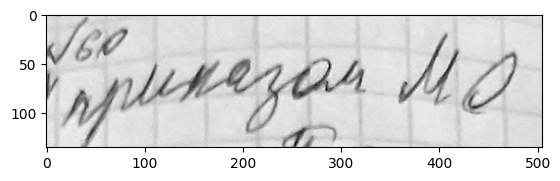

In [345]:
TRAIN_DIR = DATA_DIR+"/train"
img = cv2.imread(TRAIN_DIR + "/"+df.iloc[64130]['file'], cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')

In [346]:
df.iloc[64130]['label']

'приказом МО'

In [347]:
IM_HEIGHT = 200
IM_WIDTH = 800

image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

In [ ]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img

In [ ]:
def resize_height_keep_ratio(img):
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    scale = IM_HEIGHT / tf.cast(h, tf.float32)
    new_w = tf.cast(tf.cast(w, tf.float32) * scale, tf.int32)

    img = tf.image.resize(img, (IM_HEIGHT, new_w))
    
    current_w = tf.shape(img)[1]
    if current_w > IM_WIDTH:
        img = tf.image.resize(img, (IM_HEIGHT, IM_WIDTH))
    else:
        pad_w = IM_WIDTH - current_w
        img = tf.pad(img, [[0, 0], [0, pad_w], [0, 0]], constant_values=0.0)
    
    return img

In [350]:
def build_dataset(paths, labels, batch_size, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=1024, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, y: (resize_height_keep_ratio(load_image(p)), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )


    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)


    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


In [ ]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor=4 / 180.0,
        fill_mode="constant",
        fill_value=0.0
    ),
    tf.keras.layers.RandomZoom(
        height_factor=0.0,
        width_factor=(-0.1, 0.1),
        fill_mode="constant",
        fill_value=0.0
    ),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])


(4, 200, 800, 1)


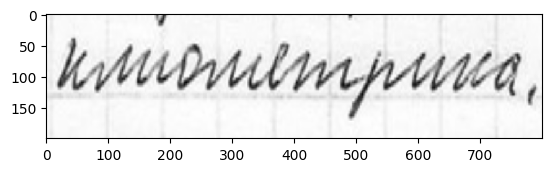

In [ ]:
train_ds = build_dataset(image_paths, labels, batch_size=32, training=True)

for batch_imgs, batch_labels in train_ds.take(1):
    print(batch_imgs.shape)  # (B, H, W, 1)
    #print(batch_labels.numpy())

    plt.imshow(batch_imgs[0, :, :, 0], cmap="gray", interpolation="nearest")
